In [1]:
import numpy as np
import matplotlib.pyplot as pl
from scipy import integrate

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)
obs_duration = 5e4

## Frequency error vs time

In [5]:
def beta_calc(f0, M):
    """M in units of solar masses"""
    Mc = M*2e30
    return const*f0**(8/3)*Mc**(5/3)

def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def freq_err(t, f0, M, delta_beta):
    """Error in the frequency from the dephasing
    M in units of solar masses
    """
    beta = beta_calc(f0, M)
    temp0 = (6*pi*f0*delta_beta)/(5*beta*(1-8/3*beta*t)**(3/8))
    temp1 = 1+(-1+beta*t)/(1-8/3*beta*t)
    return temp0*temp1

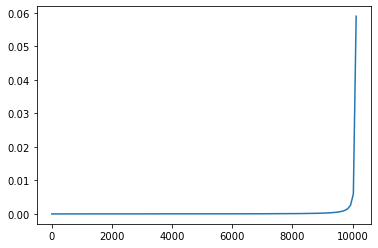

In [7]:
f0 = 20
M = 1e-1
beta = beta_calc(f0, M)
T = min(obs_duration, t_max_calc(f0, beta, 200))
delta_beta = 1e-11

t_space = np.logspace(0, np.log10(T), 1000)
err_arr = abs(freq_err(t_space, f0, M, delta_beta))
pl.plot(t_space, err_arr)

In [8]:
idx = np.argmin(abs(err_arr - 1/T))
crossover_t = t_space[idx]

In [9]:
crossover_t

8180.626269163961

## Integrating to find lost power

In [15]:
def integrated_func_without_asd(t, f0, M):
    temp0 = np.power((1-8/3*beta_calc(f0, M)*t),-0.5)
    return temp0

def analytical_loss(offset_arr, T, f0, M):
    temp_arr = []
    t_space = np.logspace(0, np.log10(T), 10000)
    for i in offset_arr:
        err_arr = abs(freq_err(t_space, f0, M, i))
        idx = np.argmin(abs(err_arr - 1/(2*T)))
        crossover_t = t_space[idx]

        temp0 = integrate.quad(integrated_func_without_asd, crossover_t, T, args = (f0, M))[0] 
        temp1 = integrate.quad(integrated_func_without_asd, 0, T, args = (f0, M))[0] 
        temp_arr.append(temp0/temp1)
    return np.array(temp_arr)

In [16]:
t_space[-1]

10115.645764798895

In [17]:
offset_arr = np.logspace(-12, -8, 50)
analytical_arr = analytical_loss(offset_arr, T, f0, 1e-2)

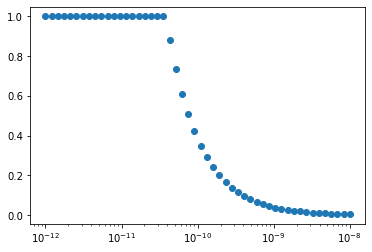

In [18]:
pl.semilogx(offset_arr, 1-analytical_arr, 'o')

In [112]:
d = 8000*3.086e+19

temp0 = (16/d**2)*(5/96)**2*(beta**2*c**2)/(pi**4*f0**4)
temp1 = integrate.quad(integrated_func_without_asd, crossover_t, T, args = (f0, M))[0]

lost_power = temp0*temp1
full_power = temp0*integrate.quad(integrated_func_without_asd, 0, T, args = (f0, M))[0]

In [113]:
lost_power/full_power

0.24289313632908238

## Comparison to numerical

In [115]:
import finufft
import matplotlib.pyplot as pl

f_max = 200
f_nufft = 3*f_max

def nufft(beta, data, t, bin_no):
    bins = np.arange(bin_no) - bin_no//2
    
    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    nufft_amp = finufft.nufft1d1(tau, data, bin_no)
    nufft_freq = -bins*scale/(2*pi)
    nufft_power = np.abs(nufft_amp/len(data))**2
    
    sort_idx = np.argsort(nufft_power)
    thresh_idx = np.searchsorted(nufft_power, np.array([0.01]), sorter=sort_idx)[0]
    return nufft_power[sort_idx[-1]]

def main_calc(f0, M, delta_beta):
    beta = beta_calc(f0, M)
    T_obs = min(5e4, t_max_calc(f0, beta, 200))
    
    t_nufft = np.arange(0, T_obs, 1/f_nufft)
    phi = -6*pi/5*f0*(1-8./3.*(beta)*t_nufft)**(5/8)/beta
    phi = np.mod(phi,2*pi)
    signal_nufft = 1*np.exp(1j*phi)
    
    ref_power = nufft(beta, signal_nufft, t_nufft, len(signal_nufft))
    result = nufft(beta+delta_beta, signal_nufft, t_nufft, len(signal_nufft))  
    return result/ref_power                    

In [124]:
# numerical = main_calc(f0, M, delta_beta)
# numerical

## Comparison to cluster

In [117]:
cluster = np.loadtxt('./cufinufft_ratio_curve.txt')

Text(0.5, 1.0, '$f_0 = 20, \\, M_c = 10^{-2}M_\\odot$')

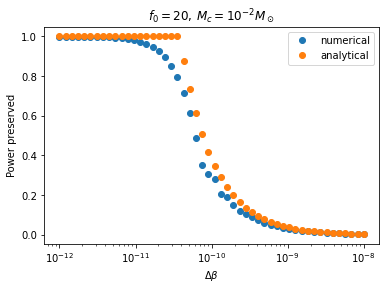

In [123]:
pl.semilogx(offset_arr, cluster, 'o', label='numerical')
pl.semilogx(offset_arr, 1-analytical_arr, 'o', label='analytical')
pl.legend()
pl.xlabel(r'$\Delta \beta$')
pl.ylabel("Power preserved")
pl.title(r'$f_0 = 20, \, M_c = 10^{-2}M_\odot$')